# Image and Video Processing Lab 3

## Task I: Histogram Creation

### Importing Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### Loading Image

In [ ]:
def show_image(img, title="Image"):
    plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

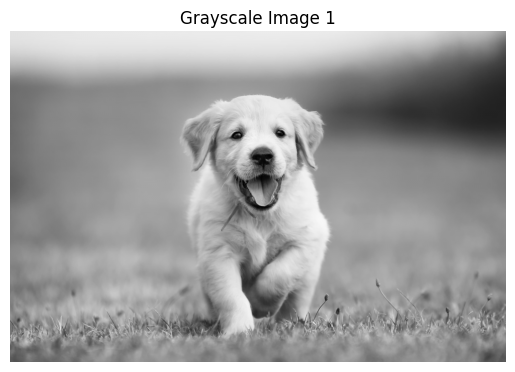

In [ ]:
img = cv2.imread('doggy.jpg')
img_gray = cv2.imread('doggy.jpg', cv2.IMREAD_GRAYSCALE)

show_image(img_gray, "Grayscale Image 1")

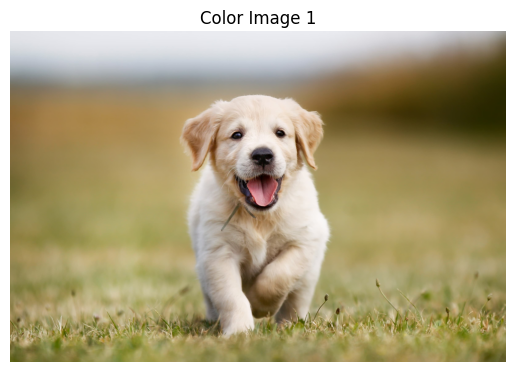

In [ ]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
channels = ('r', 'g', 'b')

show_image(img_rgb, "Color Image 1")

### Plotting histogram of the image

#### Grayscale

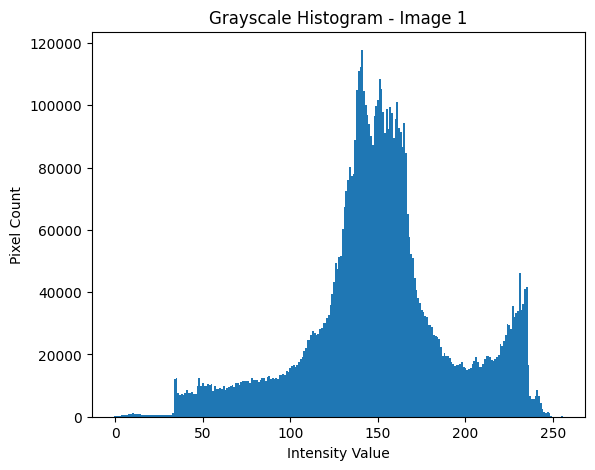

In [ ]:
plt.figure(figsize=(14,5))

x = np.arange(256)

# Image 1
plt.subplot(1, 2, 1)
hist1 = cv2.calcHist([img_gray], [0], None, [256], [0,256]).flatten()
plt.bar(x, hist1, width=1.0)
plt.title("Grayscale Histogram - Image 1")
plt.xlabel("Intensity Value")
plt.ylabel("Pixel Count")
plt.show()

#### Color

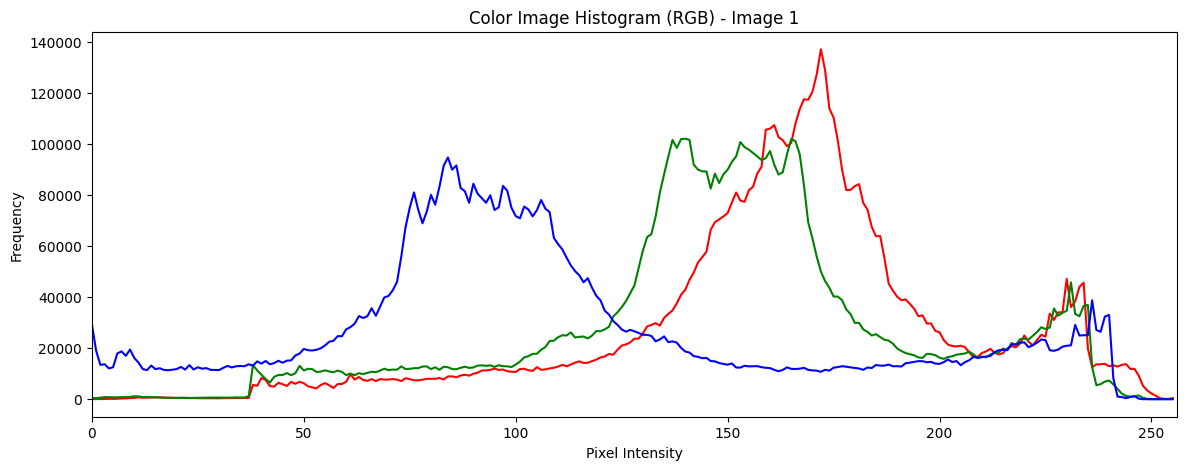

In [ ]:
plt.figure(figsize=(14,5))

for i, col in enumerate(channels):
    hist2 = cv2.calcHist([img_rgb], [i], None, [256], [0, 256])
    plt.plot(hist2, color=col)
    plt.xlim([0, 256])

plt.title("Color Image Histogram (RGB) - Image 1")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

## Task II: Histogram Equalization

### Side by side comparison of image and its histogram equalized version

#### Greyscale

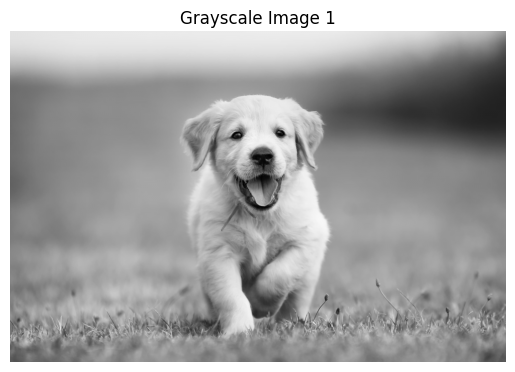

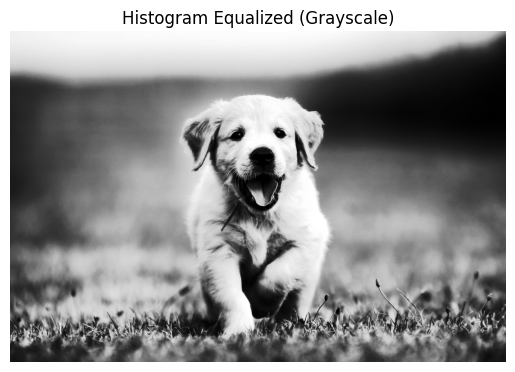

In [ ]:
gray1_eq = cv2.equalizeHist(img_gray)

show_image(img_gray, "Grayscale Image 1")
show_image(gray1_eq, "Histogram Equalized (Grayscale)")

#### Color

In [ ]:
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
hsv[:,:,2] = cv2.equalizeHist(hsv[:,:,2])

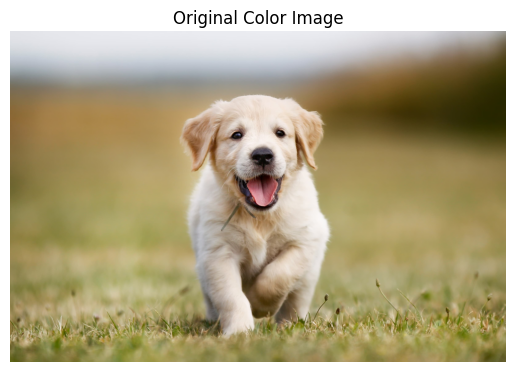

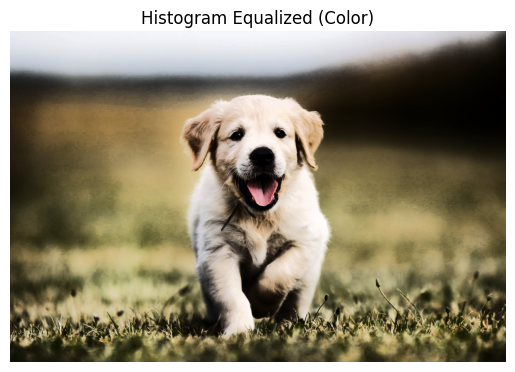

In [ ]:
eq_color = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

show_image(cv2.cvtColor(img, cv2.COLOR_BGR2RGB), "Original Color Image")
show_image(cv2.cvtColor(eq_color, cv2.COLOR_BGR2RGB), "Histogram Equalized (Color)")

### Side by side histogram plots

#### Greyscale

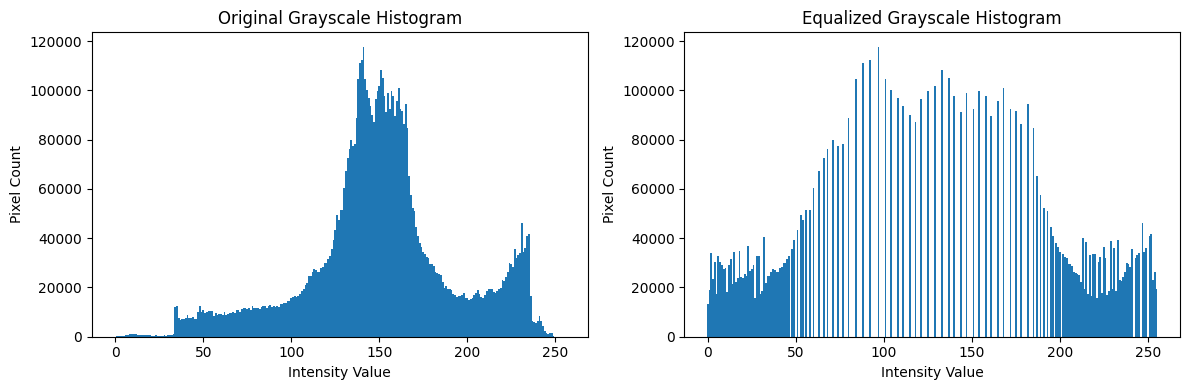

In [ ]:
hist1 = cv2.calcHist([img_gray], [0], None, [256], [0,256]).flatten()
hist_eq = cv2.calcHist([gray1_eq], [0], None, [256], [0,256]).flatten()

x = np.arange(256)

plt.figure(figsize=(12,4))

# Original
plt.subplot(1, 2, 1)
plt.bar(x, hist1, width=1.0)
plt.title("Original Grayscale Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Pixel Count")

# Equalized
plt.subplot(1, 2, 2)
plt.bar(x, hist_eq, width=1.0)
plt.title("Equalized Grayscale Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Pixel Count")

plt.tight_layout()
plt.show()


#### Color

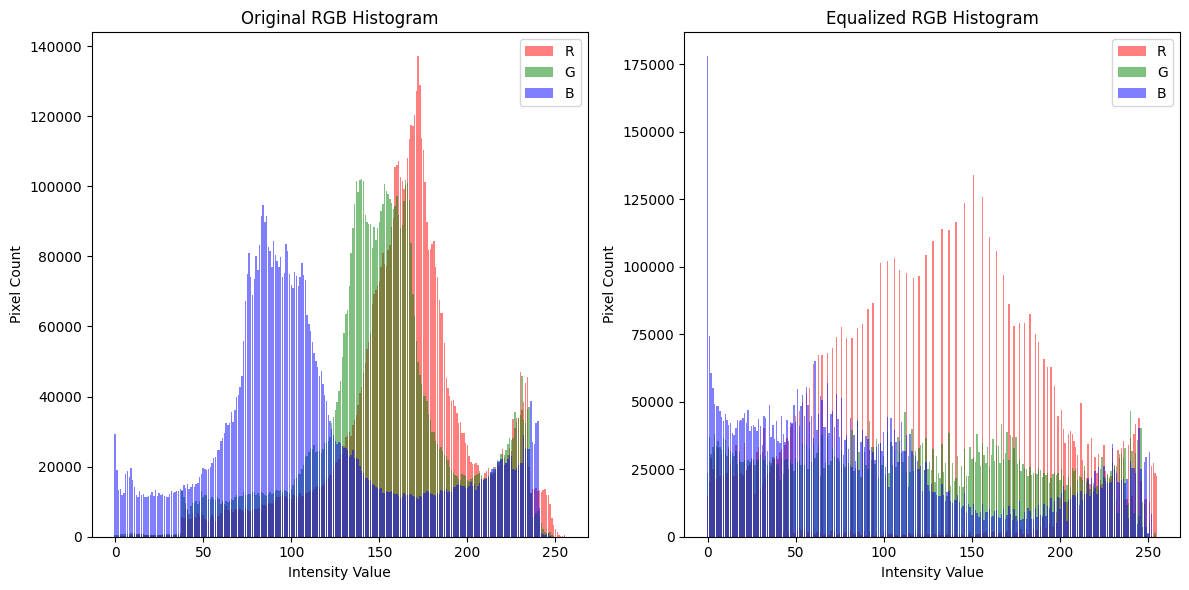

In [ ]:
hist_r = cv2.calcHist([img], [2], None, [256], [0,256]).flatten()
hist_g = cv2.calcHist([img], [1], None, [256], [0,256]).flatten()
hist_b = cv2.calcHist([img], [0], None, [256], [0,256]).flatten()

# Compute RGB histograms (Equalized)
hist_r_eq = cv2.calcHist([eq_color], [2], None, [256], [0,256]).flatten()
hist_g_eq = cv2.calcHist([eq_color], [1], None, [256], [0,256]).flatten()
hist_b_eq = cv2.calcHist([eq_color], [0], None, [256], [0,256]).flatten()

x = np.arange(256)

plt.figure(figsize=(12,6))

# Original RGB Histogram
plt.subplot(1,2,1)
plt.bar(x, hist_r, color='red', alpha=0.5, label='R')
plt.bar(x, hist_g, color='green', alpha=0.5, label='G')
plt.bar(x, hist_b, color='blue', alpha=0.5, label='B')
plt.title("Original RGB Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Pixel Count")
plt.legend()

# Equalized RGB Histogram
plt.subplot(1,2,2)
plt.bar(x, hist_r_eq, color='red', alpha=0.5, label='R')
plt.bar(x, hist_g_eq, color='green', alpha=0.5, label='G')
plt.bar(x, hist_b_eq, color='blue', alpha=0.5, label='B')
plt.title("Equalized RGB Histogram")
plt.xlabel("Intensity Value")
plt.ylabel("Pixel Count")
plt.legend()

plt.tight_layout()
plt.show()

## Task III: Histogram Modification

### Histogram Matching Using a Gaussian Target Distribution

#### Greyscale

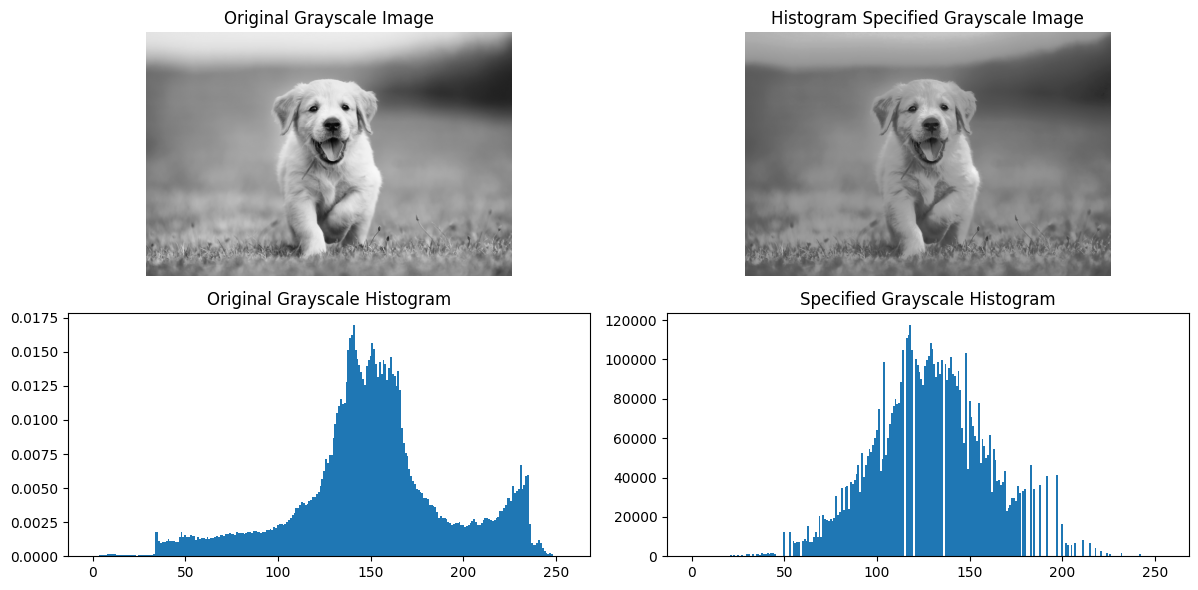

In [ ]:
# -----------------------------
# Target histogram (Gaussian)
# -----------------------------
x = np.arange(256)
target_pdf = np.exp(-((x - 128) ** 2) / (2 * 30 ** 2))
target_pdf = target_pdf / target_pdf.sum()
target_cdf = np.cumsum(target_pdf)

# -----------------------------
# Source histogram (Grayscale)
# -----------------------------
hist_gray = cv2.calcHist([img_gray], [0], None, [256], [0,256]).flatten()
hist_gray = hist_gray / hist_gray.sum()
cdf_gray = np.cumsum(hist_gray)

# -----------------------------
# Create mapping
# -----------------------------
mapping = np.zeros(256, dtype=np.uint8)
for i in range(256):
    mapping[i] = np.argmin(np.abs(cdf_gray[i] - target_cdf))

# Apply mapping
gray_modified = mapping[img_gray]

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12,6))

plt.subplot(2,2,1)
plt.imshow(img_gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(gray_modified, cmap='gray')
plt.title("Histogram Specified Grayscale Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.bar(x, hist_gray, width=1.0)
plt.title("Original Grayscale Histogram")

hist_gray_mod = cv2.calcHist([gray_modified], [0], None, [256], [0,256]).flatten()
plt.subplot(2,2,4)
plt.bar(x, hist_gray_mod, width=1.0)
plt.title("Specified Grayscale Histogram")

plt.tight_layout()
plt.show()


#### Color

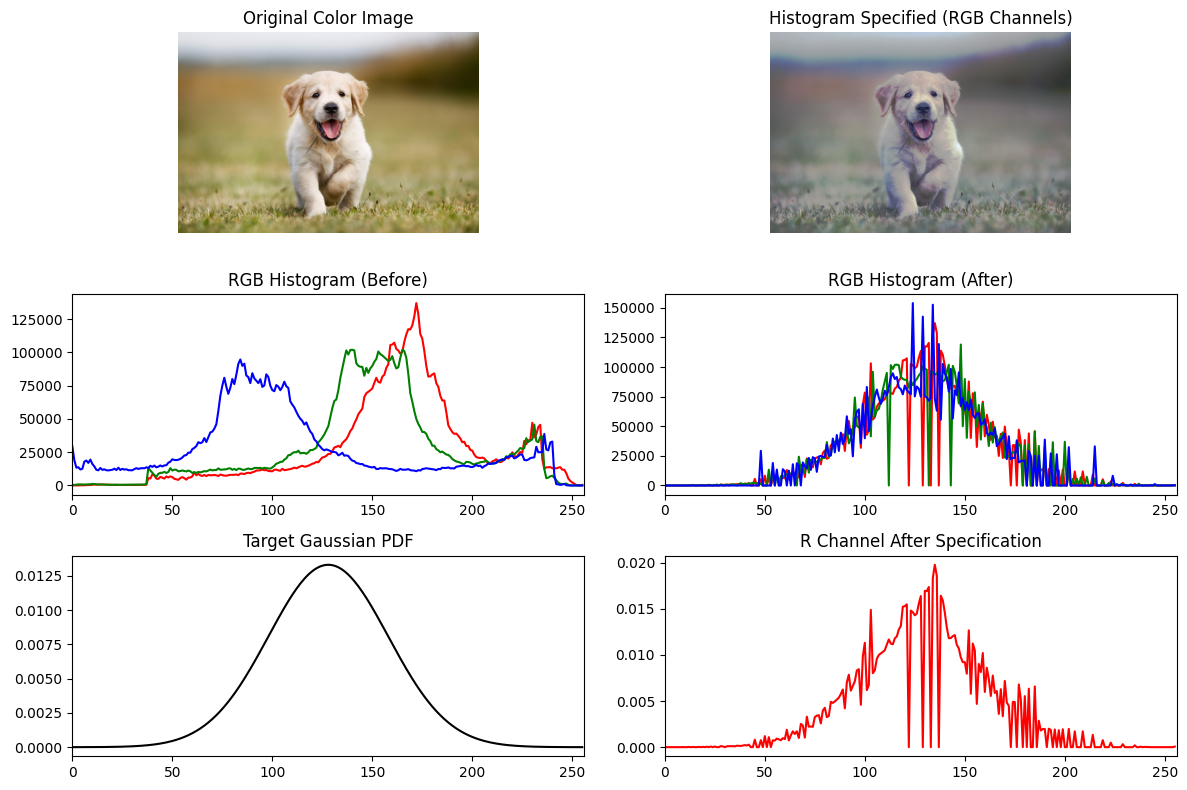

In [ ]:
# -----------------------------
# Target histogram (Gaussian)
# -----------------------------
x = np.arange(256)
target_pdf = np.exp(-((x - 128) ** 2) / (2 * 30 ** 2))
target_pdf = target_pdf / target_pdf.sum()
target_cdf = np.cumsum(target_pdf)

# -----------------------------
# Function to perform histogram specification
# -----------------------------
def hist_spec_channel(channel):
    hist, _ = np.histogram(channel.flatten(), 256, [0,256])
    hist = hist / hist.sum()
    cdf = np.cumsum(hist)

    mapping = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        mapping[i] = np.argmin(np.abs(cdf[i] - target_cdf))

    modified = mapping[channel]
    return modified, hist

# -----------------------------
# Apply to each channel
# -----------------------------
r_mod, hist_r = hist_spec_channel(img_rgb[:,:,0])
g_mod, hist_g = hist_spec_channel(img_rgb[:,:,1])
b_mod, hist_b = hist_spec_channel(img_rgb[:,:,2])

# Merge channels
img_mod = np.stack((r_mod, g_mod, b_mod), axis=2)

# -----------------------------
# Plot results
# -----------------------------
plt.figure(figsize=(12,8))

# Images
plt.subplot(3,2,1)
plt.imshow(img_rgb)
plt.title("Original Color Image")
plt.axis("off")

plt.subplot(3,2,2)
plt.imshow(img_mod)
plt.title("Histogram Specified (RGB Channels)")
plt.axis("off")

# RGB histograms BEFORE
plt.subplot(3,2,3)
for i, col in enumerate(('r','g','b')):
    hist = cv2.calcHist([img_rgb],[i],None,[256],[0,256])
    plt.plot(hist, color=col)
plt.title("RGB Histogram (Before)")
plt.xlim([0,256])

# RGB histograms AFTER
plt.subplot(3,2,4)
for i, col in enumerate(('r','g','b')):
    hist = cv2.calcHist([img_mod],[i],None,[256],[0,256])
    plt.plot(hist, color=col)
plt.title("RGB Histogram (After)")
plt.xlim([0,256])

# Target distribution
plt.subplot(3,2,5)
plt.plot(target_pdf, color='black')
plt.title("Target Gaussian PDF")
plt.xlim([0,256])

# Example: R channel after
plt.subplot(3,2,6)
hist_r_mod, _ = np.histogram(r_mod.flatten(), 256, [0,256])
hist_r_mod = hist_r_mod / hist_r_mod.sum()
plt.plot(hist_r_mod, color='red')
plt.title("R Channel After Specification")
plt.xlim([0,256])

plt.tight_layout()
plt.show()

## Task IV: Histogram Matching

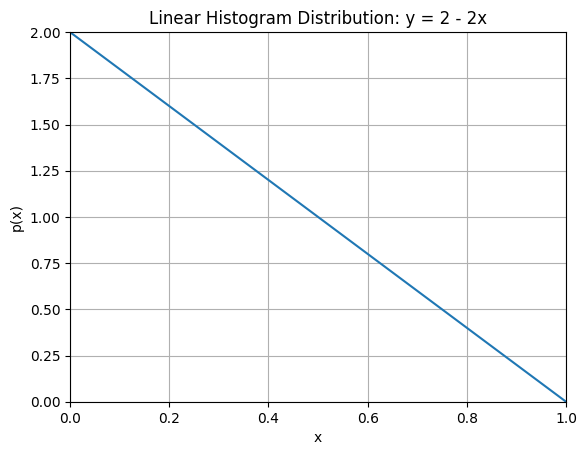

In [ ]:
# Define x values
x = np.linspace(0, 1, 256)

# Define linear distribution
y = 2 - 2*x

# Plot
plt.figure()
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("p(x)")
plt.title("Linear Histogram Distribution: y = 2 - 2x")
plt.xlim(0, 1)
plt.ylim(0, 2)
plt.grid(True)
plt.show()

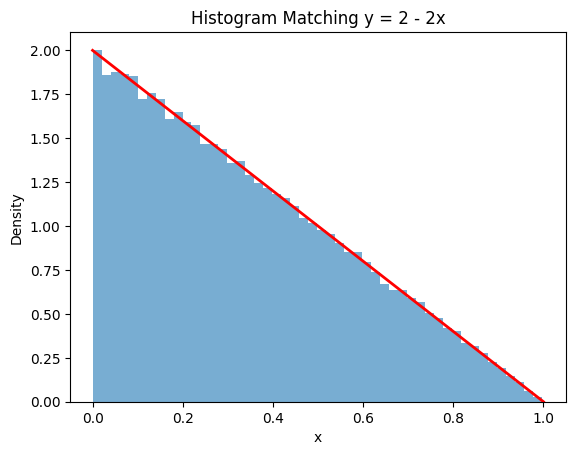

In [ ]:
u = np.random.rand(100000)
samples = 1 - np.sqrt(1 - u)

# Plot histogram
plt.hist(samples, bins=50, density=True, alpha=0.6)
plt.plot(x, y, 'r', linewidth=2)
plt.xlabel("x")
plt.ylabel("Density")
plt.title("Histogram Matching y = 2 - 2x")
plt.show()

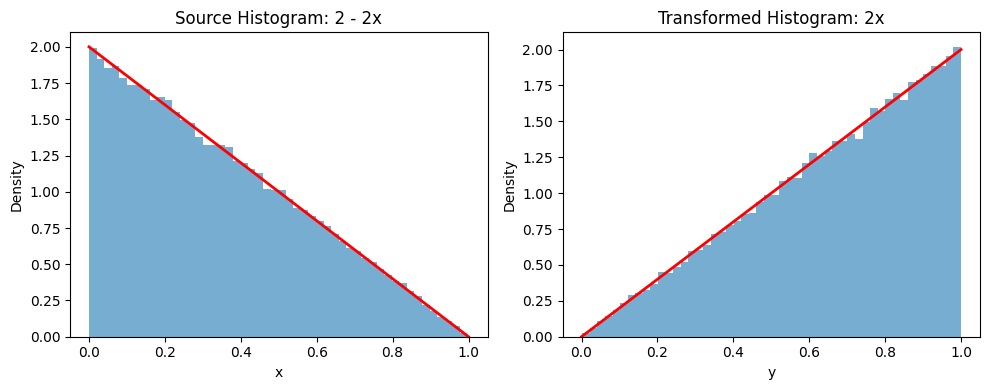

In [ ]:
# Generate samples from source distribution p(x)=2-2x
u = np.random.rand(100000)
x = 1 - np.sqrt(1 - u)   # inverse CDF of source

# Apply histogram transformation
y = np.sqrt(2*x - x**2)

# Define theoretical PDFs
t = np.linspace(0, 1, 256)
source_pdf = 2 - 2*t
target_pdf = 2*t

# Plot
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(x, bins=50, density=True, alpha=0.6)
plt.plot(t, source_pdf, 'r', linewidth=2)
plt.title("Source Histogram: 2 - 2x")
plt.xlabel("x")
plt.ylabel("Density")

plt.subplot(1,2,2)
plt.hist(y, bins=50, density=True, alpha=0.6)
plt.plot(t, target_pdf, 'r', linewidth=2)
plt.title("Transformed Histogram: 2x")
plt.xlabel("y")
plt.ylabel("Density")

plt.tight_layout()
plt.show()

## Task V: Histograms After Transformations

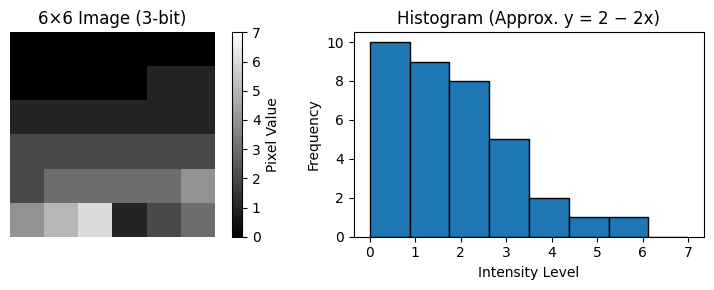

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 6x6 image with 3-bit values
img = np.array([
    [0,0,0,0,0,0],
    [0,0,0,0,1,1],
    [1,1,1,1,1,1],
    [2,2,2,2,2,2],
    [2,3,3,3,3,4],
    [4,5,6,1,2,3]
])

# Plot image
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=7)
plt.title("6×6 Image (3-bit)")
plt.colorbar(label="Pixel Value")
plt.axis("off")

# Histogram
plt.subplot(1,2,2)
plt.hist(img.flatten(), bins=8, range=(0,7), edgecolor='black')
plt.title("Histogram (Approx. y = 2 − 2x)")
plt.xlabel("Intensity Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


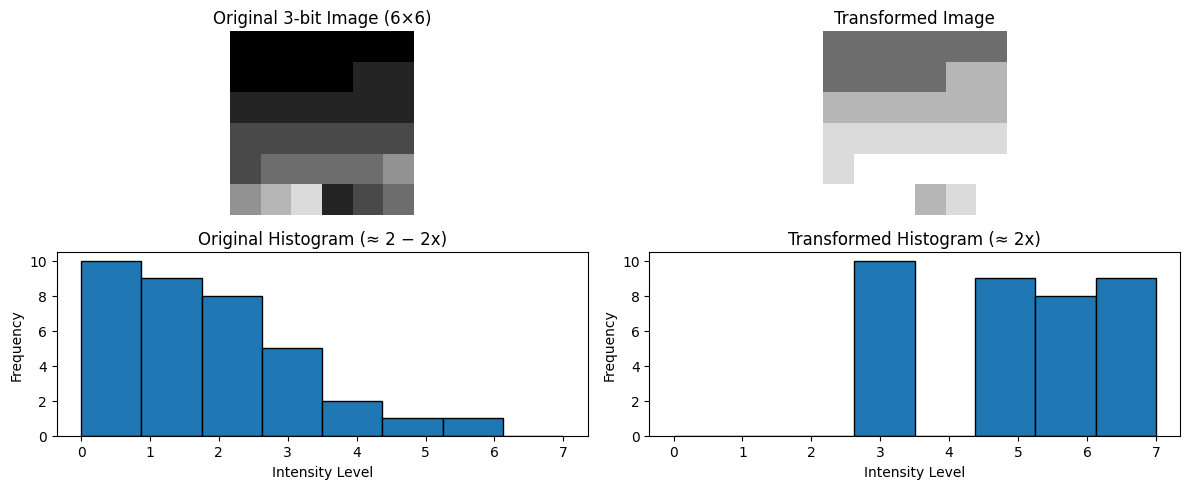

In [ ]:
# -------------------------------------------------
# Step 1: Create 6x6 image with 3-bit pixel values
# Histogram ≈ y = 2 - 2x (left-triangular)
# -------------------------------------------------
img = np.array([
    [0,0,0,0,0,0],
    [0,0,0,0,1,1],
    [1,1,1,1,1,1],
    [2,2,2,2,2,2],
    [2,3,3,3,3,4],
    [4,5,6,1,2,3]
])

L = 8  # 3-bit → 8 intensity levels

# -------------------------------------------------
# Step 2: Source histogram & CDF
# -------------------------------------------------
hist_src = np.array([np.sum(img == i) for i in range(L)])
pdf_src = hist_src / img.size
cdf_src = np.cumsum(pdf_src)

# -------------------------------------------------
# Step 3: Target histogram (right-triangular → y = 2x)
# -------------------------------------------------
levels = np.arange(L)
pdf_tgt = levels / np.sum(levels)
cdf_tgt = np.cumsum(pdf_tgt)

# -------------------------------------------------
# Step 4: Histogram transformation (CDF matching)
# -------------------------------------------------
mapping = np.zeros(L, dtype=int)
for i in range(L):
    mapping[i] = np.argmin(np.abs(cdf_src[i] - cdf_tgt))

# Apply mapping
img_transformed = mapping[img]

# -------------------------------------------------
# Step 5: Visualization
# -------------------------------------------------
plt.figure(figsize=(12,5))

# Original image
plt.subplot(2,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=7)
plt.title("Original 3-bit Image (6×6)")
plt.axis("off")

# Transformed image
plt.subplot(2,2,2)
plt.imshow(img_transformed, cmap='gray', vmin=0, vmax=7)
plt.title("Transformed Image")
plt.axis("off")

# Original histogram
plt.subplot(2,2,3)
plt.hist(img.flatten(), bins=8, range=(0,7), edgecolor='black')
plt.title("Original Histogram (≈ 2 − 2x)")
plt.xlabel("Intensity Level")
plt.ylabel("Frequency")

# Transformed histogram
plt.subplot(2,2,4)
plt.hist(img_transformed.flatten(), bins=8, range=(0,7), edgecolor='black')
plt.title("Transformed Histogram (≈ 2x)")
plt.xlabel("Intensity Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


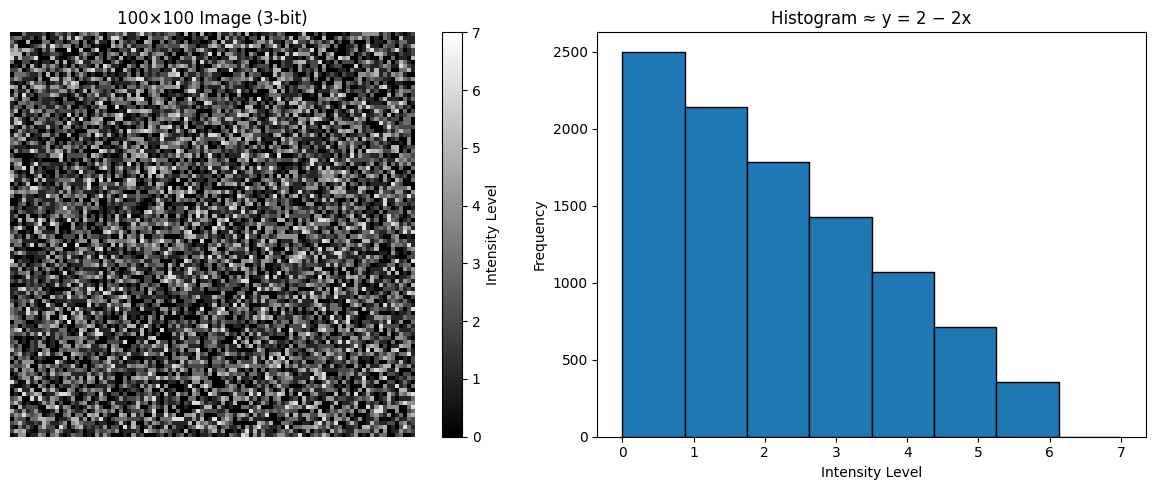

In [ ]:
# ------------------------------------
# Step 1: Define pixel counts (3-bit)
# ------------------------------------
counts = {
    0: 2500,
    1: 2143,
    2: 1786,
    3: 1429,
    4: 1071,
    5: 714,
    6: 357,
    7: 0
}

# ------------------------------------
# Step 2: Create pixel list
# ------------------------------------
pixels = []
for value, count in counts.items():
    pixels.extend([value] * count)

pixels = np.array(pixels)

# Shuffle for spatial randomness
np.random.shuffle(pixels)

# ------------------------------------
# Step 3: Reshape into 100x100 image
# ------------------------------------
img = pixels.reshape(100, 100)

# ------------------------------------
# Step 4: Plot image and histogram
# ------------------------------------
plt.figure(figsize=(12,5))

# Image
plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=7)
plt.title("100×100 Image (3-bit)")
plt.colorbar(label="Intensity Level")
plt.axis("off")

# Histogram
plt.subplot(1,2,2)
plt.hist(img.flatten(), bins=8, range=(0,7), edgecolor='black')
plt.title("Histogram ≈ y = 2 − 2x")
plt.xlabel("Intensity Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


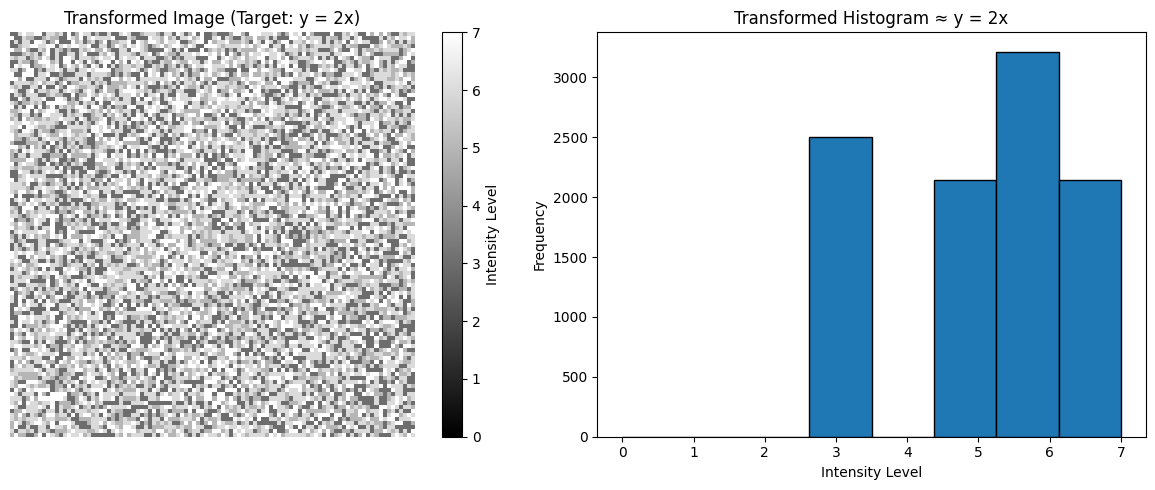

In [ ]:
# Apply histogram transformation y = 2x on the previously generated 3-bit image

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Recreate original image (100x100, 3-bit, y = 2 - 2x)
# -----------------------------
counts = {
    0: 2500,
    1: 2143,
    2: 1786,
    3: 1429,
    4: 1071,
    5: 714,
    6: 357,
    7: 0
}

pixels = []
for value, count in counts.items():
    pixels.extend([value] * count)

pixels = np.array(pixels)
np.random.shuffle(pixels)
img = pixels.reshape(100, 100)

# -----------------------------
# Step 2: Histogram Transformation using CDF (target y = 2x)
# -----------------------------
L = 8  # 3-bit levels

# Source histogram and CDF
hist_src, _ = np.histogram(img.flatten(), bins=L, range=(0, L))
pdf_src = hist_src / hist_src.sum()
cdf_src = np.cumsum(pdf_src)

# Target CDF for y = 2x
x = np.linspace(0, 1, L)
pdf_target = 2 * x
pdf_target = pdf_target / pdf_target.sum()
cdf_target = np.cumsum(pdf_target)

# Create intensity mapping
mapping = np.zeros(L, dtype=np.uint8)
for i in range(L):
    mapping[i] = np.argmin(np.abs(cdf_target - cdf_src[i]))

# Apply mapping
img_transformed = mapping[img]

# -----------------------------
# Step 3: Plot transformed image and histogram
# -----------------------------
plt.figure(figsize=(12,5))

# Transformed Image
plt.subplot(1,2,1)
plt.imshow(img_transformed, cmap='gray', vmin=0, vmax=7)
plt.title("Transformed Image (Target: y = 2x)")
plt.colorbar(label="Intensity Level")
plt.axis("off")

# Histogram
plt.subplot(1,2,2)
plt.hist(img_transformed.flatten(), bins=L, range=(0,7), edgecolor='black')
plt.title("Transformed Histogram ≈ y = 2x")
plt.xlabel("Intensity Level")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


## Task VI: PSNR, SSIM, LPIPS

In [ ]:
!pip install lpips scikit-image

### Calculating Metrics

In [ ]:
import cv2
import numpy as np
import torch
import lpips
from skimage.metrics import structural_similarity as ssim

# --- 1. Define Calculation Functions ---

def calculate_psnr(img1, img2):
    # PSNR calculation using OpenCV
    return cv2.PSNR(img1, img2)

def calculate_ssim(img1, img2):
    # SSIM calculation using scikit-image
    # Ensure images have the same dimensions and type
    return ssim(img1, img2, data_range=img2.max() - img2.min())

def calculate_lpips(img1, img2):
    # LPIPS requires images to be PyTorch tensors, normalized to [-1, 1]
    # Initialize LPIPS model (AlexNet backbone is standard)
    loss_fn = lpips.LPIPS(net='alex')

    # Preprocessing function to convert numpy image to tensor
    def preprocess(img):
        # Convert to RGB if grayscale (LPIPS expects 3 channels)
        if len(img.shape) == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

        # Normalize to [-1, 1] and transpose to (C, H, W)
        img = (img / 255.0) * 2 - 1
        img = img.transpose((2, 0, 1))
        img = torch.tensor(img).float().unsqueeze(0) # Add batch dimension
        return img

    t_img1 = preprocess(img1)
    t_img2 = preprocess(img2)

    # Calculate distance
    with torch.no_grad():
        d = loss_fn(t_img1, t_img2)
    return d.item()

# --- 2. Perform Calculations ---

# TODO: Replace 'processed_img' with the variable name of your output image from Task I/II
# Example: reference_image = img_gray
#          target_image = img_equalized

reference_image = img_gray  # The original image loaded at the start
target_image = img_gray     # REPLACE THIS with your processed image variable

# Ensure shapes match before calculation
if reference_image.shape != target_image.shape:
    target_image = cv2.resize(target_image, (reference_image.shape[1], reference_image.shape[0]))

# 1. PSNR (Higher is better)
psnr_value = calculate_psnr(reference_image, target_image)
print(f"PSNR: {psnr_value:.2f} dB")

# 2. SSIM (Closer to 1.0 is better)
ssim_value = calculate_ssim(reference_image, target_image)
print(f"SSIM: {ssim_value:.4f}")

# 3. LPIPS (Lower is better, 0 means identical)
lpips_value = calculate_lpips(reference_image, target_image)
print(f"LPIPS: {lpips_value:.4f}")

PSNR: 361.20 dB
SSIM: 1.0000
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 163MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS: 0.0000
